# Sample Extraction and Exploration

This notebook loads the `sample_artifacts` DuckDB view, runs the GitSkills static scanner across each adjacent base/derived pair within a skill-name group, exports the full sample with scanner results, and performs basic exploratory analysis.

## Safety and scope

- The DuckDB database is opened **read-only**.
- Artifact `content` is treated only as text and passed to the GitSkills regex-based static analyzer.
- Nothing contained in a sampled artifact is executed.
- The exported Parquet file preserves every column returned by `select * from sample_artifacts` and adds exactly two columns: `rules_flagged` and `scanner_json`.
- The first artifact in each name group has blank scanner fields because it has no earlier artifact in that group.

## Comparison ordering

Artifacts are processed in the order returned by the `sample_artifacts` view. The notebook does not recalculate or reinterpret the ordering dates.

Within each `name` group, every artifact after the first is compared with the artifact immediately before it. The previous derived artifact therefore becomes the next base artifact.

## Meaning of `rules_flagged`

A rule is **flagged** when its match count increases from the base artifact to the derived artifact (`delta > 0`). `rules_flagged` is the number of distinct rule IDs with a positive delta in that comparison.


## Project Imports

In [1]:
import json
import os
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from gitskills import SkillAnalyzer, compare_results


## Set Variables

In [2]:
DEFAULT_DB_PATH = Path(r"C:\data\duckdb\agent_skills_release.db")
DB_PATH = Path(os.environ.get("GITSKILLS_DB", DEFAULT_DB_PATH))

# Resolve paths whether Jupyter starts from the repository root or notebooks/.
CWD = Path.cwd().resolve()

if CWD.name == "notebooks":
    NOTEBOOK_DIR = CWD
    PROJECT_ROOT = CWD.parent
elif (CWD / "notebooks").is_dir():
    PROJECT_ROOT = CWD
    NOTEBOOK_DIR = CWD / "notebooks"
else:
    PROJECT_ROOT = CWD
    NOTEBOOK_DIR = CWD

OUTPUT_DIR = NOTEBOOK_DIR / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
OUTPUT_PARQUET = OUTPUT_DIR / "sample_artifacts_scanner_results.parquet"

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Project root:       {PROJECT_ROOT}")
print(f"Parquet output:     {OUTPUT_PARQUET}")
print(f"Figures directory:  {FIGURES_DIR}")


Notebook directory: \\boxy\home\school\umich\csc580\git\csc580-project8\notebooks\extraction_pipeline
Project root:       \\boxy\home\school\umich\csc580\git\csc580-project8\notebooks\extraction_pipeline
Parquet output:     \\boxy\home\school\umich\csc580\git\csc580-project8\notebooks\extraction_pipeline\results\sample_artifacts_scanner_results.parquet
Figures directory:  \\boxy\home\school\umich\csc580\git\csc580-project8\notebooks\extraction_pipeline\figures


## Locate Database

In [3]:
if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

print(f"Database: {DB_PATH}")
print(f"Size: {DB_PATH.stat().st_size / 1024**3:.2f} GB")

Database: C:\data\duckdb\agent_skills_release.db
Size: 37.37 GB


## Connect to DuckDB

In [4]:
conn = duckdb.connect(database=str(DB_PATH), read_only=True)
duckdb_version = conn.sql("select version()").fetchall()[0][0]

print(f"Connected to DuckDB version {duckdb_version}")

Connected to DuckDB version v1.5.5


## 1. Inspect Sample Counts

Compare the number of rows in `sample_artifacts` with the number of distinct `file_sha` values. Equal counts indicate that the sample has no exact content duplicates based on the dataset file hash.

In [5]:
sample_counts = conn.sql("""
    select
        count(*) as total_artifacts,
        count(distinct file_sha) as distinct_file_sha
    from sample_artifacts
""").df()

sample_counts


,total_artifacts,distinct_file_sha
0,43,43


## 2. Inspect Artifact Order

Show the artifact identifiers and date fields in the order returned by the `sample_artifacts` view.

In [6]:
artifact_order_fields = conn.sql("""
    select id, name, dedup_primary, file_sha, first_commit_at, repo_created_at
    from sample_artifacts
""").df()

artifact_order_fields


,id,name,dedup_primary,file_sha,first_commit_at,repo_created_at
0,603780,003-create-golang-project,1,348f7a56f87d01cb9c10b9aac82b04dbdd8c163d,NaN,2026-02-22T16:34:17Z
1,485589,003-create-golang-project,1,4c64854a9b7b41777cf7ff7aafaf882e1609a83f,NaN,2026-03-04T00:42:06Z
2,603780,003-create-golang-project,1,2941934ac0db60b9a3888ee9da82396ef063af07,NaN,2026-04-12T19:45:27Z
3,603780,003-create-golang-project,1,cc5c501649ef678b79dc30b98c62462981ea1b4f,NaN,2026-05-28T23:02:08Z
4,360715,1k-defi-module-integration,1,676a02971f9b8575506f6d628150f35dd3936f09,2026-04-15T21:39:25Z,2026-04-15T21:55:27Z
5,423459,1k-defi-module-integration,1,dc438bccc86934026118a6bf27980698d5789456,2026-05-01T00:13:08Z,2026-01-21T06:17:51Z
6,423459,1k-defi-module-integration,1,442effea7c7b6ccf9cef7e4d59bcfacce74d9d08,2026-06-03T07:00:18Z,2026-06-03T06:59:05Z
7,250589,1k-defi-module-integration,1,c6949d376537f3d07c306268572d98265a0fff88,NaN,2021-11-22T14:54:51Z
8,440693,A/B Test Setup,1,ed296841d6309ef9b0db917097b2f9f1c266fd87,NaN,2026-02-23T07:48:29Z
9,18177,A/B Test Setup,1,2c6007053f203da30f40b2017a75181a608c1b65,NaN,2026-06-05T15:55:29Z


## 3. List Distinct Sample Names

In [7]:
name_summary = (
    artifact_order_fields.groupby("name", sort=False, dropna=False)
    .size()
    .reset_index(name="artifact_count")
)

print(f"Distinct names: {len(name_summary)}")
for name in name_summary["name"]:
    print(f"- {name}")

name_summary


Distinct names: 10
- 003-create-golang-project
- 1k-defi-module-integration
- A/B Test Setup
- argent-react-native-app-workflow
- capacitor-best-practices
- cometchat-core
- cursor-subagent-creator
- databricks-upgrade-migration
- ghostclaw
- legacy-migration-planner


,name,artifact_count
0,003-create-golang-project,4
1,1k-defi-module-integration,4
2,A/B Test Setup,2
3,argent-react-native-app-workflow,5
4,capacitor-best-practices,3
5,cometchat-core,5
6,cursor-subagent-creator,5
7,databricks-upgrade-migration,5
8,ghostclaw,5
9,legacy-migration-planner,5


## 4. Load the Full Sample

Load every column from the view. These original columns are preserved in the exported Parquet file.

In [8]:
sample_artifacts = conn.sql("""
    select * from sample_artifacts
""").df()

SOURCE_COLUMNS = sample_artifacts.columns.tolist()

print(f"Loaded {len(sample_artifacts)} artifacts and {len(SOURCE_COLUMNS)} source columns.")

sample_artifacts


Loaded 43 artifacts and 24 source columns.


,id,artifact_id,repo_id,name,normalized_description,artifact_group_size,sibling_file_count,sibling_content_sha,file_sha,path,...,history_fetched,first_commit_at,composition_fetched,dedup_primary,sibling_count,has_scripts,content_sha_ok,repo_name,repo_owner,repo_created_at
0,603780,2244377,162936,003-create-golang-project,scaffolds the initial boilerplate structure fo...,3,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,348f7a56f87d01cb9c10b9aac82b04dbdd8c163d,.xdrs/agentme/edrs/application/skills/003-crea...,...,0,NaN,1,1,0,0,1,flaviostutz/filedist,flaviostutz,2026-02-22T16:34:17Z
1,485589,2386173,165213,003-create-golang-project,scaffolds the initial boilerplate structure fo...,1,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,4c64854a9b7b41777cf7ff7aafaf882e1609a83f,.xdrs/agentme/edrs/application/skills/003-crea...,...,0,NaN,1,1,0,0,1,flaviostutz/agentme,flaviostutz,2026-03-04T00:42:06Z
2,603780,1970318,162284,003-create-golang-project,scaffolds the initial boilerplate structure fo...,3,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,2941934ac0db60b9a3888ee9da82396ef063af07,.xdrs/agentme/edrs/application/skills/003-crea...,...,0,NaN,1,1,0,0,1,flaviostutz/testprompt,flaviostutz,2026-04-12T19:45:27Z
3,603780,2386167,204279,003-create-golang-project,scaffolds the initial boilerplate structure fo...,3,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,cc5c501649ef678b79dc30b98c62462981ea1b4f,.xdrs/agentme/edrs/application/skills/003-crea...,...,0,NaN,1,1,0,0,1,flaviostutz/deepworkflow,flaviostutz,2026-05-28T23:02:08Z
4,360715,2696303,63828,1k-defi-module-integration,guide for integrating new defi modules or prot...,1,6,05c4cf576dc7bbc733b2aeb31c70f0d628b70c346ae2fd...,676a02971f9b8575506f6d628150f35dd3936f09,.claude/skills/1k-defi-module-integration/SKIL...,...,1,2026-04-15T21:39:25Z,1,1,6,0,1,wanghaisheng/web3-scaffold-app-monorepo,wanghaisheng,2026-04-15T21:55:27Z
5,423459,3076631,261,1k-defi-module-integration,interactive guide for integrating new defi mod...,2,<NA>,NaN,dc438bccc86934026118a6bf27980698d5789456,Dataset/Skills/malware/1k-defi-module-integrat...,...,1,2026-05-01T00:13:08Z,1,1,1,1,1,lxyeternal/MalSkillBench,lxyeternal,2026-01-21T06:17:51Z
6,423459,2723114,3936,1k-defi-module-integration,interactive guide for integrating new defi mod...,2,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,442effea7c7b6ccf9cef7e4d59bcfacce74d9d08,.agents/skills/1k-defi-module-integration/SKIL...,...,1,2026-06-03T07:00:18Z,1,1,0,0,1,MikeCheng1208/BattleTree,MikeCheng1208,2026-06-03T06:59:05Z
7,250589,2498630,78873,1k-defi-module-integration,"onekey app defi integration for earn, borrow, ...",1,18,b6f86e95318c8321d4cd970045ef78f469cc55ff6821df...,c6949d376537f3d07c306268572d98265a0fff88,.skillshare/skills/1k-defi-module-integration/...,...,0,NaN,1,1,18,0,1,OneKeyHQ/app-monorepo,OneKeyHQ,2021-11-22T14:54:51Z
8,440693,2690162,47889,A/B Test Setup,"use this skill when setting up, improving, or ...",1,1,90d76d7e4b1dce5f90e9e3f5f4080dda182aa9ceb3c5b4...,ed296841d6309ef9b0db917097b2f9f1c266fd87,skills/ab-test-setup/SKILL.md,...,0,NaN,1,1,1,0,1,ChatAndBuild/chatchat-skills,ChatAndBuild,2026-02-23T07:48:29Z
9,18177,1244165,58628,A/B Test Setup,"use when planning, designing, or implementing ...",1,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,2c6007053f203da30f40b2017a75181a608c1b65,mindpalace/skills/global/marketing/ab-test-set...,...,0,NaN,1,1,0,0,1,aashutosh396/mindpalace,aashutosh396,2026-06-05T15:55:29Z


## 5. Initialize the GitSkills Scanner

The active rule catalog is read directly from `gitskills`. Each rule's `category` value is used for category-level analysis, so the notebook stays aligned with the scanner definitions instead of maintaining a separate mapping.

In [9]:
analyzer = SkillAnalyzer()

rule_catalog = pd.DataFrame(
    [
        {
            "rule_id": rule.rule_id,
            "category": rule.category.value,
            "description": rule.description,
        }
        for rule in analyzer.rules
    ]
)

RULE_CATEGORY = dict(zip(rule_catalog["rule_id"], rule_catalog["category"]))
RULE_DESCRIPTION = dict(zip(rule_catalog["rule_id"], rule_catalog["description"]))

rule_catalog

,rule_id,category,description
0,CMD-001,command_execution,Shell command block detected
1,CMD-002,command_execution,Command invocation detected
2,NET-001,network_access,HTTP or HTTPS URL detected
3,NET-002,network_access,Network client usage detected
4,FS-001,filesystem_access,File-system command detected
5,FS-002,filesystem_access,File-writing API detected
6,CRED-001,credential_access,Credential or secret reference detected
7,CRED-002,credential_access,Credential file reference detected
8,EXT-001,external_code_execution,Downloaded content is piped to a shell interpr...
9,EXT-002,external_code_execution,External package installation detected


### Scanner Helper

In [10]:
def artifact_validation_reason(row):
    """Return a reason when an artifact cannot be scanned."""

    reasons = []

    if pd.isna(row.get("name")) or not str(row.get("name")).strip():
        reasons.append("missing name")

    if pd.isna(row.get("file_sha")) or not str(row.get("file_sha")).strip():
        reasons.append("missing file_sha")

    content = row.get("content")
    if pd.isna(content) or not str(content).strip():
        reasons.append("missing content")

    return "; ".join(reasons)


def scan_pair(base_text, derived_text):
    """Run the same core analyzer/comparator used by scan_diff on two text values."""

    base_result = analyzer.scan(str(base_text))
    derived_result = analyzer.scan(str(derived_text))
    comparison = compare_results(base_result, derived_result)

    positive_rule_deltas = [
        rule_delta
        for rule_delta in comparison.rule_deltas
        if rule_delta.delta > 0
    ]

    return len(positive_rule_deltas), comparison.to_dict(verbose=True)


## 6. Scan Adjacent Artifacts and Build the Export

Artifacts are processed in the order returned by the view. For each `name` group, the first row is the initial base and receives no scanner result. Every later row is scanned against the immediately preceding row in that same group. The comparison result is attached to the **derived row**.

This produces one output row per sample artifact rather than duplicating base/derived rows for every pair.


In [11]:
output_df = sample_artifacts[SOURCE_COLUMNS].copy()
output_df["rules_flagged"] = pd.array([pd.NA] * len(output_df), dtype="Int64")
output_df["scanner_json"] = pd.NA

scan_log = []

for name, group in sample_artifacts.groupby("name", sort=False, dropna=False):
    group_indexes = group.index.to_list()

    for base_index, derived_index in zip(group_indexes, group_indexes[1:]):
        base_row = sample_artifacts.loc[base_index]
        derived_row = sample_artifacts.loc[derived_index]

        base_reason = artifact_validation_reason(base_row)
        derived_reason = artifact_validation_reason(derived_row)

        if base_reason or derived_reason:
            scan_log.append(
                {
                    "name": name,
                    "base_index": base_index,
                    "derived_index": derived_index,
                    "base_id": base_row.get("id"),
                    "derived_id": derived_row.get("id"),
                    "base_file_sha": base_row.get("file_sha"),
                    "derived_file_sha": derived_row.get("file_sha"),
                    "status": "skipped",
                    "reason": (
                        f"base: {base_reason or 'valid'}; "
                        f"derived: {derived_reason or 'valid'}"
                    ),
                    "rules_flagged": pd.NA,
                }
            )
            continue

        rules_flagged, payload = scan_pair(
            base_row["content"],
            derived_row["content"],
        )

        output_df.at[derived_index, "rules_flagged"] = rules_flagged
        output_df.at[derived_index, "scanner_json"] = json.dumps(
            payload,
            ensure_ascii=False,
            sort_keys=True,
            separators=(",", ":"),
        )

        scan_log.append(
            {
                "name": name,
                "base_index": base_index,
                "derived_index": derived_index,
                "base_id": base_row.get("id"),
                "derived_id": derived_row.get("id"),
                "base_file_sha": base_row.get("file_sha"),
                "derived_file_sha": derived_row.get("file_sha"),
                "status": "scanned",
                "reason": "",
                "rules_flagged": rules_flagged,
            }
        )

scan_log_df = pd.DataFrame(scan_log)

print(f"Artifact rows prepared: {len(output_df)}")
print(f"Name groups:            {sample_artifacts['name'].nunique(dropna=True)}")
print(f"Pair opportunities:     {len(scan_log_df)}")
print(f"Pairs scanned:          {(scan_log_df['status'] == 'scanned').sum() if not scan_log_df.empty else 0}")
print(f"Pairs skipped:          {(scan_log_df['status'] == 'skipped').sum() if not scan_log_df.empty else 0}")

scan_log_df


Artifact rows prepared: 43
Name groups:            10
Pair opportunities:     33
Pairs scanned:          33
Pairs skipped:          0


,name,base_index,derived_index,base_id,derived_id,base_file_sha,derived_file_sha,status,reason,rules_flagged
0,003-create-golang-project,0,1,603780,485589,348f7a56f87d01cb9c10b9aac82b04dbdd8c163d,4c64854a9b7b41777cf7ff7aafaf882e1609a83f,scanned,,0
1,003-create-golang-project,1,2,485589,603780,4c64854a9b7b41777cf7ff7aafaf882e1609a83f,2941934ac0db60b9a3888ee9da82396ef063af07,scanned,,0
2,003-create-golang-project,2,3,603780,603780,2941934ac0db60b9a3888ee9da82396ef063af07,cc5c501649ef678b79dc30b98c62462981ea1b4f,scanned,,1
3,1k-defi-module-integration,4,5,360715,423459,676a02971f9b8575506f6d628150f35dd3936f09,dc438bccc86934026118a6bf27980698d5789456,scanned,,5
4,1k-defi-module-integration,5,6,423459,423459,dc438bccc86934026118a6bf27980698d5789456,442effea7c7b6ccf9cef7e4d59bcfacce74d9d08,scanned,,0
5,1k-defi-module-integration,6,7,423459,250589,442effea7c7b6ccf9cef7e4d59bcfacce74d9d08,c6949d376537f3d07c306268572d98265a0fff88,scanned,,1
6,A/B Test Setup,8,9,440693,18177,ed296841d6309ef9b0db917097b2f9f1c266fd87,2c6007053f203da30f40b2017a75181a608c1b65,scanned,,0
7,argent-react-native-app-workflow,10,11,292573,292573,eba0c797519ec7eab8d6b3e9ec5905b604a26a76,d4e0a4bad3649052d52c70bf695caba5c7e7d258,scanned,,0
8,argent-react-native-app-workflow,11,12,292573,292573,d4e0a4bad3649052d52c70bf695caba5c7e7d258,0861656372406937987d36f189179badb1b1f8a4,scanned,,0
9,argent-react-native-app-workflow,12,13,292573,292573,0861656372406937987d36f189179badb1b1f8a4,cd167e2bba1ee61eeafeb40a25e19424910973fb,scanned,,2


## 7. Save the Parquet File

In [12]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

duckdb.from_df(output_df).write_parquet(str(OUTPUT_PARQUET))

print(f"Saved {len(output_df)} rows to: {OUTPUT_PARQUET}")


Saved 43 rows to: \\boxy\home\school\umich\csc580\git\csc580-project8\notebooks\extraction_pipeline\results\sample_artifacts_scanner_results.parquet


## 8. Reload the Parquet File for Analysis

In [13]:
analysis_df = duckdb.read_parquet(str(OUTPUT_PARQUET)).df()
analysis_df["rules_flagged"] = pd.to_numeric(
    analysis_df["rules_flagged"], errors="coerce"
).astype("Int64")

print(f"Reloaded {len(analysis_df)} rows from Parquet.")
analysis_df


Reloaded 43 rows from Parquet.


,id,artifact_id,repo_id,name,normalized_description,artifact_group_size,sibling_file_count,sibling_content_sha,file_sha,path,...,composition_fetched,dedup_primary,sibling_count,has_scripts,content_sha_ok,repo_name,repo_owner,repo_created_at,rules_flagged,scanner_json
0,603780,2244377,162936,003-create-golang-project,scaffolds the initial boilerplate structure fo...,3,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,348f7a56f87d01cb9c10b9aac82b04dbdd8c163d,.xdrs/agentme/edrs/application/skills/003-crea...,...,1,1,0,0,1,flaviostutz/filedist,flaviostutz,2026-02-22T16:34:17Z,<NA>,NaN
1,485589,2386173,165213,003-create-golang-project,scaffolds the initial boilerplate structure fo...,1,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,4c64854a9b7b41777cf7ff7aafaf882e1609a83f,.xdrs/agentme/edrs/application/skills/003-crea...,...,1,1,0,0,1,flaviostutz/agentme,flaviostutz,2026-03-04T00:42:06Z,0,"{""base"":{""profile"":{""command_execution"":true,""..."
2,603780,1970318,162284,003-create-golang-project,scaffolds the initial boilerplate structure fo...,3,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,2941934ac0db60b9a3888ee9da82396ef063af07,.xdrs/agentme/edrs/application/skills/003-crea...,...,1,1,0,0,1,flaviostutz/testprompt,flaviostutz,2026-04-12T19:45:27Z,0,"{""base"":{""profile"":{""command_execution"":true,""..."
3,603780,2386167,204279,003-create-golang-project,scaffolds the initial boilerplate structure fo...,3,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,cc5c501649ef678b79dc30b98c62462981ea1b4f,.xdrs/agentme/edrs/application/skills/003-crea...,...,1,1,0,0,1,flaviostutz/deepworkflow,flaviostutz,2026-05-28T23:02:08Z,1,"{""base"":{""profile"":{""command_execution"":true,""..."
4,360715,2696303,63828,1k-defi-module-integration,guide for integrating new defi modules or prot...,1,6,05c4cf576dc7bbc733b2aeb31c70f0d628b70c346ae2fd...,676a02971f9b8575506f6d628150f35dd3936f09,.claude/skills/1k-defi-module-integration/SKIL...,...,1,1,6,0,1,wanghaisheng/web3-scaffold-app-monorepo,wanghaisheng,2026-04-15T21:55:27Z,<NA>,NaN
5,423459,3076631,261,1k-defi-module-integration,interactive guide for integrating new defi mod...,2,<NA>,NaN,dc438bccc86934026118a6bf27980698d5789456,Dataset/Skills/malware/1k-defi-module-integrat...,...,1,1,1,1,1,lxyeternal/MalSkillBench,lxyeternal,2026-01-21T06:17:51Z,5,"{""base"":{""profile"":{""command_execution"":false,..."
6,423459,2723114,3936,1k-defi-module-integration,interactive guide for integrating new defi mod...,2,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,442effea7c7b6ccf9cef7e4d59bcfacce74d9d08,.agents/skills/1k-defi-module-integration/SKIL...,...,1,1,0,0,1,MikeCheng1208/BattleTree,MikeCheng1208,2026-06-03T06:59:05Z,0,"{""base"":{""profile"":{""command_execution"":true,""..."
7,250589,2498630,78873,1k-defi-module-integration,"onekey app defi integration for earn, borrow, ...",1,18,b6f86e95318c8321d4cd970045ef78f469cc55ff6821df...,c6949d376537f3d07c306268572d98265a0fff88,.skillshare/skills/1k-defi-module-integration/...,...,1,1,18,0,1,OneKeyHQ/app-monorepo,OneKeyHQ,2021-11-22T14:54:51Z,1,"{""base"":{""profile"":{""command_execution"":false,..."
8,440693,2690162,47889,A/B Test Setup,"use this skill when setting up, improving, or ...",1,1,90d76d7e4b1dce5f90e9e3f5f4080dda182aa9ceb3c5b4...,ed296841d6309ef9b0db917097b2f9f1c266fd87,skills/ab-test-setup/SKILL.md,...,1,1,1,0,1,ChatAndBuild/chatchat-skills,ChatAndBuild,2026-02-23T07:48:29Z,<NA>,NaN
9,18177,1244165,58628,A/B Test Setup,"use when planning, designing, or implementing ...",1,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,2c6007053f203da30f40b2017a75181a608c1b65,mindpalace/skills/global/marketing/ab-test-set...,...,1,1,0,0,1,aashutosh396/mindpalace,aashutosh396,2026-06-05T15:55:29Z,0,"{""base"":{""profile"":{""command_execution"":false,..."


## 9. Pair-Level Detection Summary

In [14]:
scanned_pair_mask = analysis_df["scanner_json"].notna()
flagged_pair_mask = scanned_pair_mask & analysis_df["rules_flagged"].fillna(0).gt(0)

pairs_scanned = int(scanned_pair_mask.sum())
pairs_flagged = int(flagged_pair_mask.sum())
flagged_pair_pct = (pairs_flagged / pairs_scanned * 100) if pairs_scanned else 0.0

pair_summary = pd.DataFrame(
    [
        {"metric": "Sample artifacts", "count": len(analysis_df)},
        {"metric": "Distinct name groups", "count": analysis_df["name"].nunique()},
        {"metric": "Artifact pairs scanned", "count": pairs_scanned},
        {"metric": "Pairs with >= 1 flagged rule", "count": pairs_flagged},
    ]
)

print(f"Flagged pair rate: {pairs_flagged}/{pairs_scanned} ({flagged_pair_pct:.1f}%)")

pair_summary

Flagged pair rate: 13/33 (39.4%)


,metric,count
0,Sample artifacts,43
1,Distinct name groups,10
2,Artifact pairs scanned,33
3,Pairs with >= 1 flagged rule,13


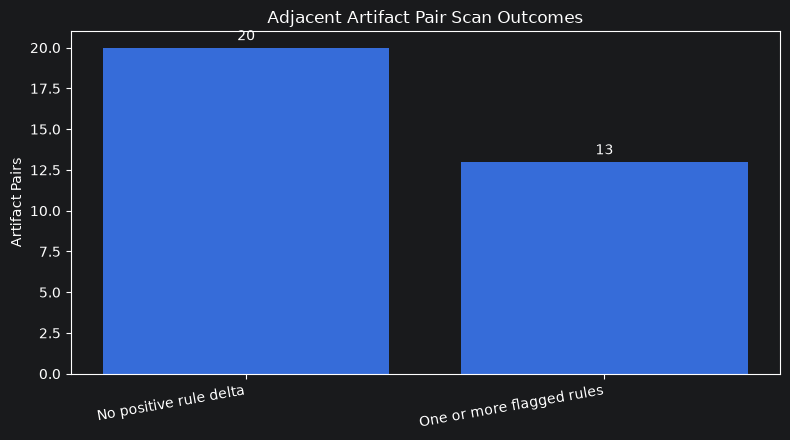

Saved: \\boxy\home\school\umich\csc580\git\csc580-project8\notebooks\extraction_pipeline\figures\pair_scan_outcomes.png


In [15]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pair_plot = pd.DataFrame(
    {
        "outcome": ["No positive rule delta", "One or more flagged rules"],
        "count": [pairs_scanned - pairs_flagged, pairs_flagged],
    }
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(pair_plot["outcome"], pair_plot["count"])
ax.set_title("Adjacent Artifact Pair Scan Outcomes")
ax.set_ylabel("Artifact Pairs")
ax.set_xlabel("")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xticks(rotation=10, ha="right")
plt.tight_layout()

pair_figure_path = FIGURES_DIR / "pair_scan_outcomes.png"
fig.savefig(pair_figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {pair_figure_path}")

## 10. Flagged Rules

Count how many scanned pairs produced a positive delta for each active rule. The `positive_match_delta` column sums the increases in match counts across those pairs.

In [16]:
flag_records = []

for row_index, row in analysis_df.loc[scanned_pair_mask].iterrows():
    payload = json.loads(row["scanner_json"])

    for rule_id, delta_values in payload.get("rule_deltas", {}).items():
        delta = int(delta_values.get("delta", 0))
        if delta <= 0:
            continue

        flag_records.append(
            {
                "row_index": row_index,
                "name": row.get("name"),
                "derived_file_sha": row.get("file_sha"),
                "rule_id": rule_id,
                "category": RULE_CATEGORY.get(rule_id, "unknown"),
                "description": RULE_DESCRIPTION.get(rule_id, ""),
                "base_matches": int(delta_values.get("base", 0)),
                "derived_matches": int(delta_values.get("derived", 0)),
                "delta": delta,
            }
        )

flags_df = pd.DataFrame(
    flag_records,
    columns=[
        "row_index",
        "name",
        "derived_file_sha",
        "rule_id",
        "category",
        "description",
        "base_matches",
        "derived_matches",
        "delta",
    ],
)

rule_counts = rule_catalog.merge(
    (
        flags_df.groupby("rule_id")
        .agg(
            pairs_flagged=("rule_id", "size"),
            positive_match_delta=("delta", "sum"),
        )
        .reset_index()
        if not flags_df.empty
        else pd.DataFrame(columns=["rule_id", "pairs_flagged", "positive_match_delta"])
    ),
    on="rule_id",
    how="left",
)

rule_counts["pairs_flagged"] = rule_counts["pairs_flagged"].fillna(0).astype(int)
rule_counts["positive_match_delta"] = rule_counts["positive_match_delta"].fillna(0).astype(int)

rule_counts = rule_counts.sort_values(
    ["pairs_flagged", "positive_match_delta", "rule_id"],
    ascending=[False, False, True],
).reset_index(drop=True)

rule_counts

,rule_id,category,description,pairs_flagged,positive_match_delta
0,CMD-002,command_execution,Command invocation detected,7,24
1,EXT-002,external_code_execution,External package installation detected,7,12
2,NET-001,network_access,HTTP or HTTPS URL detected,7,12
3,CMD-001,command_execution,Shell command block detected,5,8
4,SYS-002,system_modification,System modification command detected,3,3
5,CRED-002,credential_access,Credential file reference detected,2,7
6,FS-002,filesystem_access,File-writing API detected,1,4
7,CRED-001,credential_access,Credential or secret reference detected,1,3
8,FS-001,filesystem_access,File-system command detected,1,3
9,NET-002,network_access,Network client usage detected,1,1


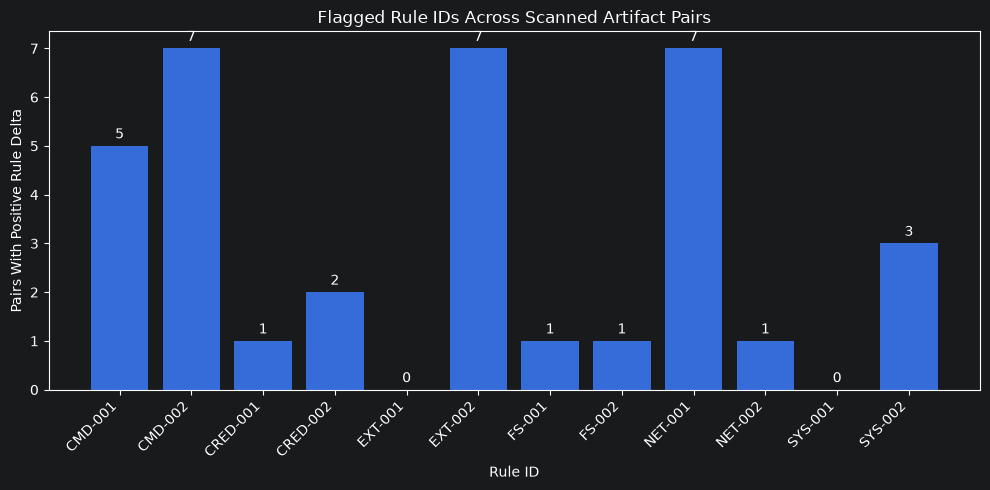

Saved: \\boxy\home\school\umich\csc580\git\csc580-project8\notebooks\extraction_pipeline\figures\flagged_rules.png


In [17]:
plot_rule_counts = rule_counts.sort_values("rule_id").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_rule_counts["rule_id"], plot_rule_counts["pairs_flagged"])
ax.set_title("Flagged Rule IDs Across Scanned Artifact Pairs")
ax.set_xlabel("Rule ID")
ax.set_ylabel("Pairs With Positive Rule Delta")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

rule_figure_path = FIGURES_DIR / "flagged_rules.png"
fig.savefig(rule_figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {rule_figure_path}")

## 11. Flagged Risk Categories

Aggregate the positive rule deltas by the category assigned to each active GitSkills rule. `flagged_rule_events` counts rule IDs with a positive delta across comparisons; `positive_match_delta` sums the corresponding increases in match counts.

In [18]:
all_categories = (
    rule_catalog[["category"]]
    .drop_duplicates()
    .sort_values("category")
    .reset_index(drop=True)
)

category_counts = all_categories.merge(
    (
        flags_df.groupby("category")
        .agg(
            flagged_rule_events=("rule_id", "size"),
            positive_match_delta=("delta", "sum"),
        )
        .reset_index()
        if not flags_df.empty
        else pd.DataFrame(
            columns=["category", "flagged_rule_events", "positive_match_delta"]
        )
    ),
    on="category",
    how="left",
)

category_counts["flagged_rule_events"] = (
    category_counts["flagged_rule_events"].fillna(0).astype(int)
)
category_counts["positive_match_delta"] = (
    category_counts["positive_match_delta"].fillna(0).astype(int)
)

category_counts = category_counts.sort_values(
    ["flagged_rule_events", "positive_match_delta", "category"],
    ascending=[False, False, True],
).reset_index(drop=True)

category_counts


,category,flagged_rule_events,positive_match_delta
0,command_execution,12,32
1,network_access,8,13
2,external_code_execution,7,12
3,credential_access,3,10
4,system_modification,3,3
5,filesystem_access,2,7


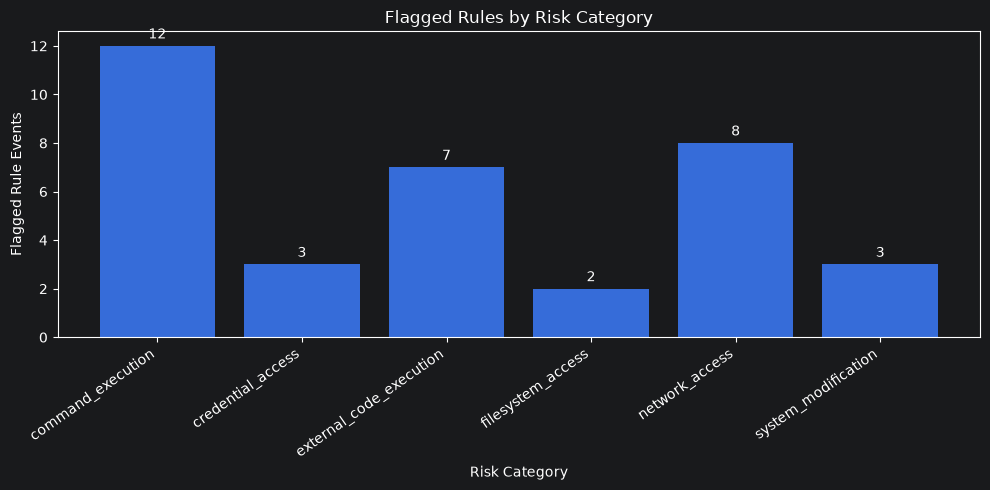

Saved: \\boxy\home\school\umich\csc580\git\csc580-project8\notebooks\extraction_pipeline\figures\flagged_risk_categories.png


In [19]:
plot_category_counts = category_counts.sort_values(
    "category"
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    plot_category_counts["category"],
    plot_category_counts["flagged_rule_events"],
)
ax.set_title("Flagged Rules by Risk Category")
ax.set_xlabel("Risk Category")
ax.set_ylabel("Flagged Rule Events")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xticks(rotation=35, ha="right")
plt.tight_layout()

category_figure_path = FIGURES_DIR / "flagged_risk_categories.png"
fig.savefig(category_figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {category_figure_path}")


## 12. Base-versus-Derived Flagged Comparisons

In [20]:
comparison_examples = []

for log_row in scan_log:
    if log_row["status"] != "scanned" or int(log_row["rules_flagged"]) == 0:
        continue

    derived_row = output_df.loc[log_row["derived_index"]]
    payload = json.loads(derived_row["scanner_json"])

    positive_deltas = {
        rule_id: values
        for rule_id, values in payload.get("rule_deltas", {}).items()
        if int(values.get("delta", 0)) > 0
    }

    flagged_categories = sorted(
        {
            RULE_CATEGORY[rule_id]
            for rule_id in positive_deltas
            if rule_id in RULE_CATEGORY
        }
    )

    comparison_examples.append(
        {
            "name": log_row["name"],
            "base_id": log_row["base_id"],
            "derived_id": log_row["derived_id"],
            "base_file_sha": log_row["base_file_sha"],
            "derived_file_sha": log_row["derived_file_sha"],
            "rules_flagged": log_row["rules_flagged"],
            "flagged_categories": ", ".join(flagged_categories),
            "positive_rule_deltas": json.dumps(positive_deltas, sort_keys=True),
        }
    )

comparison_examples_df = pd.DataFrame(comparison_examples)

if comparison_examples_df.empty:
    print("No base-versus-derived comparisons produced a positive rule delta.")

comparison_examples_df


,name,base_id,derived_id,base_file_sha,derived_file_sha,rules_flagged,flagged_categories,positive_rule_deltas
0,003-create-golang-project,603780,603780,2941934ac0db60b9a3888ee9da82396ef063af07,cc5c501649ef678b79dc30b98c62462981ea1b4f,1,filesystem_access,"{""FS-001"": {""base"": 4, ""delta"": 3, ""derived"": 7}}"
1,1k-defi-module-integration,360715,423459,676a02971f9b8575506f6d628150f35dd3936f09,dc438bccc86934026118a6bf27980698d5789456,5,"command_execution, filesystem_access, network_...","{""CMD-001"": {""base"": 0, ""delta"": 1, ""derived"":..."
2,1k-defi-module-integration,423459,250589,442effea7c7b6ccf9cef7e4d59bcfacce74d9d08,c6949d376537f3d07c306268572d98265a0fff88,1,command_execution,"{""CMD-001"": {""base"": 0, ""delta"": 1, ""derived"":..."
3,argent-react-native-app-workflow,292573,292573,0861656372406937987d36f189179badb1b1f8a4,cd167e2bba1ee61eeafeb40a25e19424910973fb,2,"command_execution, external_code_execution","{""CMD-002"": {""base"": 6, ""delta"": 3, ""derived"":..."
4,capacitor-best-practices,465490,465490,97db41d8885a5ebf43274e7d119ebc5e65e16c21,83b4cd4f10d581081bf8334b838a382da6f2949b,2,"command_execution, external_code_execution","{""CMD-002"": {""base"": 0, ""delta"": 4, ""derived"":..."
5,cometchat-core,433605,433605,6d50b2a26d91f5379998e01aa0588aad59d47658,6f4c71e38e3a24ec57da6d75b30cbe3aaad5972e,5,"command_execution, credential_access, external...","{""CMD-001"": {""base"": 3, ""delta"": 2, ""derived"":..."
6,cometchat-core,433605,433605,6f4c71e38e3a24ec57da6d75b30cbe3aaad5972e,8845d257f4cd36b181f8f920e437a30fe28686f7,5,"command_execution, credential_access, external...","{""CMD-002"": {""base"": 2, ""delta"": 3, ""derived"":..."
7,cursor-subagent-creator,351269,17639,63ca8ff11e4ce6384b4bcc504e2f573807e18d9c,abaed9363038f7f6ce17cd5b28a6cc3a7f39e106,1,network_access,"{""NET-001"": {""base"": 0, ""delta"": 1, ""derived"":..."
8,databricks-upgrade-migration,437527,437527,d4887c6b0d8ffce5faf13816cd45554dff22b640,e207a66d907506bd28e34f016bcf03625d2b7e73,3,"command_execution, external_code_execution, ne...","{""CMD-002"": {""base"": 3, ""delta"": 3, ""derived"":..."
9,databricks-upgrade-migration,437527,437527,9a448616c5ab8b1cb4df1dea2aa829413ba6f79d,2d8a202ecd04369690fd31ec8188949ec096fccd,3,"command_execution, external_code_execution, ne...","{""CMD-002"": {""base"": 3, ""delta"": 3, ""derived"":..."


## 13. Manual Finding Review

The generated table below selects up to two flagged comparisons for manual inspection. Completed reviews, the corrected first derived SHA, and persistent annotations are recorded in the Markdown section following the table.

In [21]:
manual_review_candidates = comparison_examples_df.head(2).copy()

if manual_review_candidates.empty:
    print("No flagged comparisons are available for manual review.")
else:
    manual_review_candidates["manual_label"] = "TODO"
    manual_review_candidates["annotation"] = "TODO: inspect base and derived content"

manual_review_candidates

,name,base_id,derived_id,base_file_sha,derived_file_sha,rules_flagged,flagged_categories,positive_rule_deltas,manual_label,annotation
0,003-create-golang-project,603780,603780,2941934ac0db60b9a3888ee9da82396ef063af07,cc5c501649ef678b79dc30b98c62462981ea1b4f,1,filesystem_access,"{""FS-001"": {""base"": 4, ""delta"": 3, ""derived"": 7}}",TODO,TODO: inspect base and derived content
1,1k-defi-module-integration,360715,423459,676a02971f9b8575506f6d628150f35dd3936f09,dc438bccc86934026118a6bf27980698d5789456,5,"command_execution, filesystem_access, network_...","{""CMD-001"": {""base"": 0, ""delta"": 1, ""derived"":...",TODO,TODO: inspect base and derived content


### Persistent Manual Review Annotations

| name | base_id | derived_id | base_file_sha | derived_file_sha | rules_flagged | flagged_categories | positive_rule_deltas | manual_label | annotation |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 003-create-golang-project | 603780 | 603780 | `2941934ac0db60b9a3888ee9da82396ef063af07` | **348f7a56f87d01cb9c10b9aac82b04dbdd8c163d** | 1 | filesystem_access | `{"FS-001": {"base": 4, "delta": 3, "derived": 7}}` | Supported match-count increase (corrected pair) | Derived SHA corrected; manual review of the corrected pair reproduced the expected scan output. See annotation 1. |
| 1k-defi-module-integration | 360715 | 423459 | `676a02971f9b8575506f6d628150f35dd3936f09` | `dc438bccc86934026118a6bf27980698d5789456` | 5 | command_execution, filesystem_access, network_access, system_modification | `{"CMD-001": {"base": 0, "delta": 1, "derived": ...}, ...}` | Supported newly introduced security-sensitive instructions | Added Python and Bash blocks introduce HTTP downloads, file writes, directory creation, and execution-related instructions. See annotation 2. |

**SHA correction:** The first row originally listed derived SHA `cc5c501649ef678b79dc30b98c62462981ea1b4f`. The manually reviewed derived SHA is **348f7a56f87d01cb9c10b9aac82b04dbdd8c163d**. The reviewer reported that comparing this corrected derived artifact with the listed base reproduced the expected scanner output. The original table contained a pair-SHA recording mismatch; its cause was not investigated. The IDs above are retained as supplied in the original table and have not been revalidated for the corrected SHA.

The second row's rule-delta text retains the truncation in the supplied notebook table; it is a display excerpt, not complete JSON. Its category list is expanded from the five rules identified in the notebook summary: `CMD-001`, `FS-002`, `NET-001`, `NET-002`, and `SYS-002`.

These annotations record the project team's manual inspection and persist when the notebook is rerun. The generated candidate table above may still display `TODO` and the originally recorded SHA; this section contains the completed manual review and explicit correction.

#### Annotation 1: 003-create-golang-project

**Assessment:** The corrected pair supports the reported `FS-001` match-count increase from 4 to 7. File-system access was already detected in the base, so this finding is an increase in matching instructions rather than evidence that file-system access was entirely absent from the base.

**Manual observations:**

- The overview changes the wording describing how the Makefile works and adds a Markdown link.
- A TOML code block adds specific Go dependencies.
- The Makefile code block adds mise execution, environment variables, mise installation, directory creation, and Go installation through mise.
- Further documentation about using mise appears at the end.

The directory-creation additions support the file-system finding. The other additions provide security-sensitive context, but this annotation does not assign additional scanner-rule counts to them. Wording and link changes alone do not establish executable behavior.

The originally listed derived artifact appeared as a related peer in SkillTrace rather than the intended comparison endpoint. The review uses the corrected SHA above. This confirms the reviewed text changes and scanner signal; it does not independently prove historical copying or parent-to-derived lineage.

#### Annotation 2: 1k-defi-module-integration

**Assessment:** The reviewed base and derived SHAs match the original table. Manual inspection supports newly introduced security-sensitive instructions in the added section.

**Manual observations:**

- The files are otherwise identical; the derived file adds approximately 30 lines at the bottom containing a Python code block with four defined functions.
- The added Python includes external network calls and an HTTP server address, with the description `"""Download configuration payload from remote server."""`.
- It creates directories, writes files, and adds a DLL file.
- An added Bash code block invokes `wget` and `chmod`.
- The surrounding documentation explicitly presents the Python initialization steps as key to configuring DeFi modules in the OneKey ecosystem.

**HTTP download risk:** The configuration-download HTTP call brings externally supplied content across a trust boundary into local initialization. An HTTP URL does not provide the transport encryption and server authentication supplied by HTTPS, so the payload could be exposed or modified in transit. Depending on how the downloaded configuration is used, untrusted or modified content could affect subsequent setup. This is a concrete risk to highlight alongside the file-system and execution-related additions.

This example closely matches the research question because these instructions were absent from the reviewed base. The observations support introduced network access, file-system operations, and execution-related signals. They do not establish malicious intent, runtime execution, or actual compromise; legitimate initialization remains a competing explanation.


## 14. Summary

The sample contains **43 artifacts across 10 skill-name groups**, and all 43 artifacts have distinct `file_sha` values. Processing adjacent artifacts within each name group produced **33 base-versus-derived comparisons**. All 33 comparisons were scanned successfully and none were skipped.

Of the 33 scanned pairs, **13 pairs (39.4%)** had at least one rule with a positive match-count delta, while 20 pairs had no positive rule delta. Those 13 pairs produced **35 rule-level positive-delta events** representing **77 additional rule matches** in the derived artifacts. Nine of the ten skill-name groups had at least one flagged comparison; `A/B Test Setup` was the only group with none.

The most frequently flagged individual rules were `CMD-002`, `EXT-002`, and `NET-001`, each flagged in **7 pairs**. `CMD-002` had the largest cumulative increase with **24 additional matches**, followed by `EXT-002` and `NET-001` with **12 additional matches each**. At the category level, `command_execution` had the most flagged rule events (**12**, with a cumulative positive match delta of **32**), followed by `network_access` (**8**, delta **13**) and `external_code_execution` (**7**, delta **12**). `credential_access`, `system_modification`, and `filesystem_access` occurred less frequently but were also present in the flagged comparisons.

The results also show why a positive rule delta should not automatically be interpreted as a newly introduced capability. In the `003-create-golang-project` example, `FS-001` increased from 4 to 7 matches, but file-system access was already present in the base artifact. By contrast, one `1k-defi-module-integration` comparison went from **0 scanner matches in the base to 10 in the derived artifact**, with positive deltas for `CMD-001`, `FS-002`, `NET-001`, `NET-002`, and `SYS-002`. The derived content adds network URLs, a `wget` command, file-writing operations, and a `chmod` command, making it a clear example of newly introduced security-sensitive indicators.

These results are scanner signals rather than evidence that an artifact is malicious or that the detected instructions were executed. The analysis compares artifacts in the order returned by the `sample_artifacts` view and does not establish provenance or prove that one artifact was directly derived from another. The project team's manual annotations for two examples are recorded in the persistent manual-review section, including a corrected derived SHA for the first example. This limited review does not establish overall scanner accuracy or validate the automatically generated pair metadata.


## 15. Reproduction Checklist

To reproduce the result:

1. Install the project environment so `duckdb`, `pandas`, `matplotlib`, and the local `gitskills` package are importable.
2. Set `GITSKILLS_DB` to the GitSkills DuckDB path, or place the database at the default path used above.
3. Ensure the `sample_artifacts` view exists in the database.
4. Run this notebook from top to bottom.
5. Confirm the Parquet file appears under the notebook's `output/` directory.
6. Confirm the generated figures appear in the configured `figures/` directory.


In [22]:
conn.close()
print("DuckDB connection closed.")

DuckDB connection closed.
